In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df_netflix_fee = pd.read_csv('/content/Netflix-fee.csv')

df_users = pd.read_csv('/content/users.csv')
df_movies = pd.read_csv('/content/movies.csv')
df_watch_history = pd.read_csv('/content/watch_history.csv')
df_reviews = pd.read_csv('/content/reviews.csv')


In [ ]:
# Users File
#print(df_users.shape)
#print(df_users.columns.tolist())
#print(df_users.head(2))

# Movies File
#print(df_movies.shape)
#print(df_movies.columns.tolist())
#print(df_movies.head(2))

# Watch History File
#print(df_watch_history.shape)
#print(df_watch_history.columns.tolist())
#print(df_watch_history.head(2))

# Reviews File
print(df_reviews.shape)
print(df_reviews.columns.tolist())
print(df_reviews.head(2))



(15450, 12)
['review_id', 'user_id', 'movie_id', 'rating', 'review_date', 'device_type', 'is_verified_watch', 'helpful_votes', 'total_votes', 'review_text', 'sentiment', 'sentiment_score']
       review_id     user_id    movie_id  rating review_date device_type  \
0  review_000001  user_07066  movie_0360       4  2025-03-29      Mobile   
1  review_000002  user_02953  movie_0095       5  2024-07-19      Mobile   

   is_verified_watch  helpful_votes  total_votes  \
0              False            3.0          5.0   
1               True            2.0          2.0   

                                 review_text sentiment  sentiment_score  
0  Fantastic cinematography and plot twists.  positive            0.711  
1              This series is a masterpiece!  positive            0.645  


In [ ]:
# Quick check on each File
for name, df in [("df_netflix_fee", df_netflix_fee), ("df_users", df_users), ("df_movies", df_movies),
                  ("df_watch_history", df_watch_history), ("df_reviews", df_reviews)]:
    print(f"\n{'='*40}")
    print(f"📁 {name}")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
    print(f"Duplicates: {df.duplicated().sum()}")


📁 df_netflix_fee
Shape: (65, 8)
Columns: ['Country_code', 'Country', 'Total Library Size', 'No. of TV Shows', 'No. of Movies', 'Cost Per Month - Basic ($)', 'Cost Per Month - Standard ($)', 'Cost Per Month - Premium ($)']
Missing values:
Series([], dtype: int64)
Duplicates: 0

📁 df_users
Shape: (10300, 16)
Columns: ['user_id', 'email', 'first_name', 'last_name', 'age', 'gender', 'country', 'state_province', 'city', 'subscription_plan', 'subscription_start_date', 'is_active', 'monthly_spend', 'primary_device', 'household_size', 'created_at']
Missing values:
age               1229
gender             824
monthly_spend     1017
household_size    1545
dtype: int64
Duplicates: 300

📁 df_movies
Shape: (1040, 18)
Columns: ['movie_id', 'title', 'content_type', 'genre_primary', 'genre_secondary', 'release_year', 'duration_minutes', 'rating', 'language', 'country_of_origin', 'imdb_rating', 'production_budget', 'box_office_revenue', 'number_of_seasons', 'number_of_episodes', 'is_netflix_original'

In [ ]:
# REMOVE DUPLICATES

for name, df in [("df_netflix_fee", df_netflix_fee), ("df_users", df_users),
                  ("df_movies", df_movies), ("df_watch_history", df_watch_history),
                  ("df_reviews", df_reviews)]:
    before = len(df)
    df.drop_duplicates(inplace=True)
    after = len(df)
    print(f"✅ {name}: removed {before - after} duplicates → {after} rows remaining")

✅ df_netflix_fee: removed 0 duplicates → 65 rows remaining
✅ df_users: removed 300 duplicates → 10000 rows remaining
✅ df_movies: removed 40 duplicates → 1000 rows remaining
✅ df_watch_history: removed 5000 duplicates → 100000 rows remaining
✅ df_reviews: removed 450 duplicates → 15000 rows remaining


In [ ]:
# Verify To check duplicates are gone


for name, df in [("df_netflix_fee", df_netflix_fee), ("df_users", df_users), ("df_movies", df_movies),
                  ("df_watch_history", df_watch_history), ("df_reviews", df_reviews)]:
    print(f"\n{'='*40}")
    print(f"📁 {name}")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
    print(f"Duplicates: {df.duplicated().sum()}")


📁 df_netflix_fee
Shape: (65, 8)
Columns: ['Country_code', 'Country', 'Total Library Size', 'No. of TV Shows', 'No. of Movies', 'Cost Per Month - Basic ($)', 'Cost Per Month - Standard ($)', 'Cost Per Month - Premium ($)']
Missing values:
Series([], dtype: int64)
Duplicates: 0

📁 df_users
Shape: (10300, 16)
Columns: ['user_id', 'email', 'first_name', 'last_name', 'age', 'gender', 'country', 'state_province', 'city', 'subscription_plan', 'subscription_start_date', 'is_active', 'monthly_spend', 'primary_device', 'household_size', 'created_at']
Missing values:
age               1229
gender             824
monthly_spend     1017
household_size    1545
dtype: int64
Duplicates: 300

📁 df_movies
Shape: (1040, 18)
Columns: ['movie_id', 'title', 'content_type', 'genre_primary', 'genre_secondary', 'release_year', 'duration_minutes', 'rating', 'language', 'country_of_origin', 'imdb_rating', 'production_budget', 'box_office_revenue', 'number_of_seasons', 'number_of_episodes', 'is_netflix_original'

In [ ]:
# Fix country column — rename to lowercase to match across datasets
df_netflix_fee.rename(columns={'Country': 'country'}, inplace=True)

# Strip whitespace from all string columns
for df in [df_netflix_fee, df_users, df_movies, df_watch_history, df_reviews]:
    df.columns = df.columns.str.strip()

print(" Column names cleaned!")
print(df_netflix_fee.columns.tolist())

 Column names cleaned!
['Country_code', 'country', 'Total Library Size', 'No. of TV Shows', 'No. of Movies', 'Cost Per Month - Basic ($)', 'Cost Per Month - Standard ($)', 'Cost Per Month - Premium ($)']


In [ ]:
#  Merge Dataset 2 files
# Step 1 — watch history + movie details
watch_movies = df_watch_history.merge(df_movies, on='movie_id', how='left')
print(f"watch + movies: {watch_movies.shape}")

# Step 2 — add user info
watch_users = watch_movies.merge(df_users, on='user_id', how='left')
print(f"+ users: {watch_users.shape}")

# Step 3 — add reviews
df_main = watch_users.merge(
    df_reviews[['user_id', 'movie_id', 'rating', 'sentiment', 'sentiment_score']],
    on=['user_id', 'movie_id'], how='left'
)
print(f"+ reviews: {df_main.shape}")

watch + movies: (109237, 29)
+ users: (112546, 44)
+ reviews: (112551, 47)


In [ ]:
# Merge Dataset 1 and Dataset 2
# Check country name match
print("Dataset 2 countries:", sorted(df_users['country'].unique()))
print("\nDataset 1 countries:", sorted(df_netflix_fee['country'].unique()))

#  Fix country name mismatch

# Replace 'USA' in Dataset 2 users to match Dataset 1 'United States'
df_users['country'] = df_users['country'].replace('USA', 'United States')

# Verify fix
print("Country names fixed!")
print("Unique countries in users:", sorted(df_users['country'].unique()))

Dataset 2 countries: ['Canada', 'USA']

Dataset 1 countries: ['Argentina', 'Australia', 'Austria', 'Belgium', 'Bolivia', 'Brazil', 'Bulgaria', 'Canada', 'Chile', 'Colombia', 'Costa Rica', 'Croatia', 'Czechia', 'Denmark', 'Ecuador', 'Estonia', 'Finland', 'France', 'Germany', 'Gibraltar', 'Greece', 'Guatemala', 'Honduras', 'Hong Kong', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Ireland', 'Israel', 'Italy', 'Japan', 'Latvia', 'Liechtenstein', 'Lithuania', 'Malaysia', 'Mexico', 'Moldova', 'Monaco', 'Netherlands', 'New Zealand', 'Norway', 'Paraguay', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Romania', 'Russia', 'San Marino', 'Singapore', 'Slovakia', 'South Africa', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'Taiwan', 'Thailand', 'Turkey', 'Ukraine', 'United Kingdom', 'United States', 'Uruguay', 'Venezuela']
Country names fixed!
Unique countries in users: ['Canada', 'United States']


In [ ]:
# Merge on country
df_full = df_main.merge(df_netflix_fee, on='country', how='left')
print(f"\n✅ Final merged dataset: {df_full.shape}")
print(f"Columns: {df_full.columns.tolist()}")


✅ Final merged dataset: (112551, 54)
Columns: ['session_id', 'user_id', 'movie_id', 'watch_date', 'device_type', 'watch_duration_minutes', 'progress_percentage', 'action', 'quality', 'location_country', 'is_download', 'user_rating', 'title', 'content_type', 'genre_primary', 'genre_secondary', 'release_year', 'duration_minutes', 'rating_x', 'language', 'country_of_origin', 'imdb_rating', 'production_budget', 'box_office_revenue', 'number_of_seasons', 'number_of_episodes', 'is_netflix_original', 'added_to_platform', 'content_warning', 'email', 'first_name', 'last_name', 'age', 'gender', 'country', 'state_province', 'city', 'subscription_plan', 'subscription_start_date', 'is_active', 'monthly_spend', 'primary_device', 'household_size', 'created_at', 'rating_y', 'sentiment', 'sentiment_score', 'Country_code', 'Total Library Size', 'No. of TV Shows', 'No. of Movies', 'Cost Per Month - Basic ($)', 'Cost Per Month - Standard ($)', 'Cost Per Month - Premium ($)']


In [ ]:
print("🔍 Final dataset overview")
print(f"Total rows: {len(df_full)}")
print(f"Total columns: {len(df_full.columns)}")
print(f"\nMissing values (top 10):")
print(df_full.isnull().sum().sort_values(ascending=False).head(10))
print(f"\nSample row:")
df_full.head(2)

🔍 Final dataset overview
Total rows: 112551
Total columns: 54

Missing values (top 10):
sentiment_score               112424
rating_y                      112414
sentiment                     112414
user_rating                    89942
number_of_seasons              81238
Cost Per Month - Basic ($)     79042
No. of TV Shows                79042
Total Library Size             79042
Country_code                   79042
No. of Movies                  79042
dtype: int64

Sample row:


,session_id,user_id,movie_id,watch_date,device_type,watch_duration_minutes,progress_percentage,action,quality,location_country,...,rating_y,sentiment,sentiment_score,Country_code,Total Library Size,No. of TV Shows,No. of Movies,Cost Per Month - Basic ($),Cost Per Month - Standard ($),Cost Per Month - Premium ($)
0,session_000001,user_07271,movie_0511,2025-11-13,Tablet,63.9,34.6,completed,HD,USA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,session_000002,user_00861,movie_0588,2025-02-26,Laptop,120.1,44.2,started,HD,USA,...,NaN,NaN,NaN,ca,6239.0,4311.0,1928.0,7.91,11.87,15.03


In [ ]:
# Fix Missing values in individual files

# --- df_users ---
df_users['age']            = df_users['age'].fillna(df_users['age'].median())
df_users['gender']         = df_users['gender'].fillna('Unknown')
df_users['monthly_spend']  = df_users['monthly_spend'].fillna(df_users['monthly_spend'].median())
df_users['household_size'] = df_users['household_size'].fillna(df_users['household_size'].median())
print(" df_users done")

# --- df_movies ---
df_movies['genre_secondary']   = df_movies['genre_secondary'].fillna('None')
df_movies['imdb_rating']       = df_movies['imdb_rating'].fillna(df_movies['imdb_rating'].median())
df_movies['number_of_seasons'] = df_movies['number_of_seasons'].fillna(0)
df_movies['number_of_episodes']= df_movies['number_of_episodes'].fillna(0)
#df_movies.drop(columns=['production_budget', 'box_office_revenue'], inplace=True)
print(" df_movies done")

# --- df_watch_history ---
df_watch_history['watch_duration_minutes'] = df_watch_history['watch_duration_minutes'].fillna(df_watch_history['watch_duration_minutes'].median())
df_watch_history['progress_percentage']    = df_watch_history['progress_percentage'].fillna(df_watch_history['progress_percentage'].median())
#df_watch_history.drop(columns=['user_rating'], inplace=True)
print(" df_watch_history done")

# --- df_reviews ---
df_reviews['helpful_votes']   = df_reviews['helpful_votes'].fillna(0)
df_reviews['total_votes']     = df_reviews['total_votes'].fillna(0)
df_reviews['review_text']     = df_reviews['review_text'].fillna('No review')
df_reviews['sentiment_score'] = df_reviews['sentiment_score'].fillna(df_reviews['sentiment_score'].median())
print(" df_reviews done")

print("\n All missing values fixed — no warnings!")

 df_users done
 df_movies done
 df_watch_history done
 df_reviews done

 All missing values fixed — no warnings!


In [ ]:
# DATA TYPES CHECK


for name, df in [("df_netflix_fee", df_netflix_fee), ("df_users", df_users),
                  ("df_movies", df_movies), ("df_watch_history", df_watch_history),
                  ("df_reviews", df_reviews)]:
    print(f"\n{'='*45}")
    print(f" {name}")
    print(df.dtypes)


 df_netflix_fee
Country_code                      object
country                           object
Total Library Size                 int64
No. of TV Shows                    int64
No. of Movies                      int64
Cost Per Month - Basic ($)       float64
Cost Per Month - Standard ($)    float64
Cost Per Month - Premium ($)     float64
dtype: object

 df_users
user_id                     object
email                       object
first_name                  object
last_name                   object
age                        float64
gender                      object
country                     object
state_province              object
city                        object
subscription_plan           object
subscription_start_date     object
is_active                     bool
monthly_spend              float64
primary_device              object
household_size             float64
created_at                  object
dtype: object

 df_movies
movie_id                object
title        

In [ ]:
# FIX DATA TYPES


# --- df_users ---
df_users['age']                     = df_users['age'].astype(int)
df_users['household_size']          = df_users['household_size'].astype(int)
df_users['subscription_start_date'] = pd.to_datetime(df_users['subscription_start_date'])
df_users['created_at']              = pd.to_datetime(df_users['created_at'])
print(" df_users done")

# --- df_movies ---
df_movies['duration_minutes']   = df_movies['duration_minutes'].astype(int)
df_movies['number_of_seasons']  = df_movies['number_of_seasons'].astype(int)
df_movies['number_of_episodes'] = df_movies['number_of_episodes'].astype(int)
df_movies['added_to_platform']  = pd.to_datetime(df_movies['added_to_platform'])
print(" df_movies done")

# --- df_watch_history ---
df_watch_history['watch_date']              = pd.to_datetime(df_watch_history['watch_date'])
df_watch_history['watch_duration_minutes']  = df_watch_history['watch_duration_minutes'].astype(int)
df_watch_history['progress_percentage']     = df_watch_history['progress_percentage'].astype(int)
print(" df_watch_history done")

# --- df_reviews ---
df_reviews['review_date']    = pd.to_datetime(df_reviews['review_date'])
df_reviews['helpful_votes']  = df_reviews['helpful_votes'].astype(int)
df_reviews['total_votes']    = df_reviews['total_votes'].astype(int)
print(" df_reviews done")

print("\n All data types fixed!")

 df_users done
 df_movies done
 df_watch_history done
 df_reviews done

 All data types fixed!


In [ ]:
# Recheck Data types
for name, df in [("df_netflix_fee", df_netflix_fee), ("df_users", df_users),
                  ("df_movies", df_movies), ("df_watch_history", df_watch_history),
                  ("df_reviews", df_reviews)]:
    print(f"\n{'='*45}")
    print(f" {name}")
    print(df.dtypes)


 df_netflix_fee
Country_code                      object
country                           object
Total Library Size                 int64
No. of TV Shows                    int64
No. of Movies                      int64
Cost Per Month - Basic ($)       float64
Cost Per Month - Standard ($)    float64
Cost Per Month - Premium ($)     float64
dtype: object

 df_users
user_id                            object
email                              object
first_name                         object
last_name                          object
age                                 int64
gender                             object
country                            object
state_province                     object
city                               object
subscription_plan                  object
subscription_start_date    datetime64[ns]
is_active                            bool
monthly_spend                     float64
primary_device                     object
household_size                      int64


In [ ]:
print(f"Total rows     : {len(df_full):,}")
print(f"Total columns  : {len(df_full.columns)}")
print(f"Missing values : {df_full.isnull().sum().sum()}")
print(f"Duplicates     : {df_full.duplicated().sum()}")
print("\n✅ Ready for EDA!")

Total rows     : 100,001
Total columns  : 54
Missing values : 1289054
Duplicates     : 0

✅ Ready for EDA!


In [ ]:

# CHECK MISSING IN df_full

missing = df_full.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pct = (missing / len(df_full)) * 100
df_missing = pd.DataFrame({'Missing Count': missing, 'Percentage %': pct.round(1)})
print(df_missing)

                               Missing Count  Percentage %
sentiment_score                       112424          99.9
rating_y                              112414          99.9
sentiment                             112414          99.9
user_rating                            89942          79.9
number_of_seasons                      81238          72.2
Total Library Size                     79042          70.2
No. of TV Shows                        79042          70.2
Cost Per Month - Standard ($)          79042          70.2
Cost Per Month - Basic ($)             79042          70.2
Cost Per Month - Premium ($)           79042          70.2
No. of Movies                          79042          70.2
Country_code                           79042          70.2
number_of_episodes                     77849          69.2
box_office_revenue                     76768          68.2
production_budget                      73027          64.9
genre_secondary                        72314          64

In [ ]:

# FIX df_full MISSING VALUES


# Group 2 — fill with median/unknown
df_full['age']                    = df_full['age'].fillna(df_full['age'].median())
df_full['gender']                 = df_full['gender'].fillna('Unknown')
df_full['monthly_spend']          = df_full['monthly_spend'].fillna(df_full['monthly_spend'].median())
df_full['household_size']         = df_full['household_size'].fillna(df_full['household_size'].median())
df_full['watch_duration_minutes'] = df_full['watch_duration_minutes'].fillna(df_full['watch_duration_minutes'].median())
df_full['progress_percentage']    = df_full['progress_percentage'].fillna(df_full['progress_percentage'].median())
df_full['imdb_rating']            = df_full['imdb_rating'].fillna(df_full['imdb_rating'].median())
print("✅ Group 2 — filled with median/unknown")

# Group 3 — drop columns that reappeared
df_full.drop(columns=['production_budget', 'box_office_revenue',
                       'user_rating'], inplace=True, errors='ignore')
print("✅ Group 3 — dropped unreliable columns")

# Group 1 — leave as NaN (expected from merge)
print("✅ Group 1 — price/library/sentiment columns left as NaN (used separately)")

print(f"\n✅ df_full shape now : {df_full.shape}")
print(f"Remaining missing   : {df_full.isnull().sum().sum():,}")

✅ Group 2 — filled with median/unknown
✅ Group 3 — dropped unreliable columns
✅ Group 1 — price/library/sentiment columns left as NaN (used separately)

✅ df_full shape now : (100001, 51)
Remaining missing   : 997,579


In [ ]:
# Check remaining missing — should only be Group 1 columns
missing = df_full.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pct = (missing / len(df_full)) * 100
df_missing = pd.DataFrame({'Missing Count': missing, 'Percentage %': pct.round(1)})
print(df_missing)
print("\n✅ Only expected missing values remain — ready for EDA!")

                               Missing Count  Percentage %
sentiment_score                       112424          99.9
rating_y                              112414          99.9
sentiment                             112414          99.9
user_rating                            89942          79.9
number_of_seasons                      81238          72.2
Total Library Size                     79042          70.2
No. of TV Shows                        79042          70.2
Cost Per Month - Standard ($)          79042          70.2
Cost Per Month - Basic ($)             79042          70.2
Cost Per Month - Premium ($)           79042          70.2
No. of Movies                          79042          70.2
Country_code                           79042          70.2
number_of_episodes                     77849          69.2
box_office_revenue                     76768          68.2
production_budget                      73027          64.9
genre_secondary                        72314          64

In [ ]:
# ============================================
# SECTION 1 — DATASET OVERVIEW
# ============================================

print("=" * 55)
print("   NETFLIX SUBSCRIPTION ANALYSIS — OVERVIEW")
print("=" * 55)

# Dataset 1
print(f"\n📊 Dataset 1 — Netflix Pricing by Country")
print(f"   Total countries          : {df_netflix_fee.shape[0]}")
print(f"   Plans available          : Basic, Standard, Premium")
print(f"   Avg Basic price          : ${df_netflix_fee['Cost Per Month - Basic ($)'].mean():.2f}")
print(f"   Avg Standard price       : ${df_netflix_fee['Cost Per Month - Standard ($)'].mean():.2f}")
print(f"   Avg Premium price        : ${df_netflix_fee['Cost Per Month - Premium ($)'].mean():.2f}")
print(f"   Cheapest country (Basic) : ${df_netflix_fee['Cost Per Month - Basic ($)'].min()} "
      f"— {df_netflix_fee.loc[df_netflix_fee['Cost Per Month - Basic ($)'].idxmin(), 'country']}")
print(f"   Priciest country (Basic) : ${df_netflix_fee['Cost Per Month - Basic ($)'].max()} "
      f"— {df_netflix_fee.loc[df_netflix_fee['Cost Per Month - Basic ($)'].idxmax(), 'country']}")

# Dataset 2
print(f"\n Dataset 2 — User Behavior")
print(f"   Total users              : {df_users.shape[0]:,}")
print(f"   Total movies/shows       : {df_movies.shape[0]:,}")
print(f"   Total watch sessions     : {df_watch_history.shape[0]:,}")
print(f"   Total reviews            : {df_reviews.shape[0]:,}")

# Plans
print(f"\n Subscription Plan Distribution")
plan_counts = df_users['subscription_plan'].value_counts()
for plan, count in plan_counts.items():
    pct = (count / len(df_users)) * 100
    print(f"   {plan:<20} : {count:,} users ({pct:.1f}%)")

# Countries
print(f"\n Top 5 Countries by Users")
top_countries = df_users['country'].value_counts().head()
for country, count in top_countries.items():
    pct = (count / len(df_users)) * 100
    print(f"   {country:<20} : {count:,} users ({pct:.1f}%)")

# Content
print(f"\n Content Type Breakdown")
content_counts = df_movies['content_type'].value_counts()
for ctype, count in content_counts.items():
    pct = (count / len(df_movies)) * 100
    print(f"   {ctype:<20} : {count:,} titles ({pct:.1f}%)")

# Devices
print(f"\n Device Usage")
device_counts = df_watch_history['device_type'].value_counts()
for device, count in device_counts.items():
    pct = (count / len(df_watch_history)) * 100
    print(f"   {device:<20} : {count:,} sessions ({pct:.1f}%)")

# Genres
print(f"\n Top 5 Genres")
top_genres = df_movies['genre_primary'].value_counts().head()
for genre, count in top_genres.items():
    pct = (count / len(df_movies)) * 100
    print(f"   {genre:<20} : {count:,} titles ({pct:.1f}%)")

print(f"\n{'=' * 55}")
print(f"    Overview complete!")
print(f"{'=' * 55}")

   NETFLIX SUBSCRIPTION ANALYSIS — OVERVIEW

📊 Dataset 1 — Netflix Pricing by Country
   Total countries          : 65
   Plans available          : Basic, Standard, Premium
   Avg Basic price          : $8.37
   Avg Standard price       : $11.99
   Avg Premium price        : $15.61
   Cheapest country (Basic) : $1.97 — Turkey
   Priciest country (Basic) : $12.88 — Liechtenstein

 Dataset 2 — User Behavior
   Total users              : 10,300
   Total movies/shows       : 1,040
   Total watch sessions     : 105,000
   Total reviews            : 15,450

 Subscription Plan Distribution
   Standard             : 3,625 users (35.2%)
   Premium              : 3,619 users (35.1%)
   Basic                : 2,020 users (19.6%)
   Premium+             : 1,036 users (10.1%)

 Top 5 Countries by Users
   USA                  : 7,204 users (69.9%)
   Canada               : 3,096 users (30.1%)

 Content Type Breakdown
   Movie                : 458 titles (44.0%)
   TV Series            : 267 titles

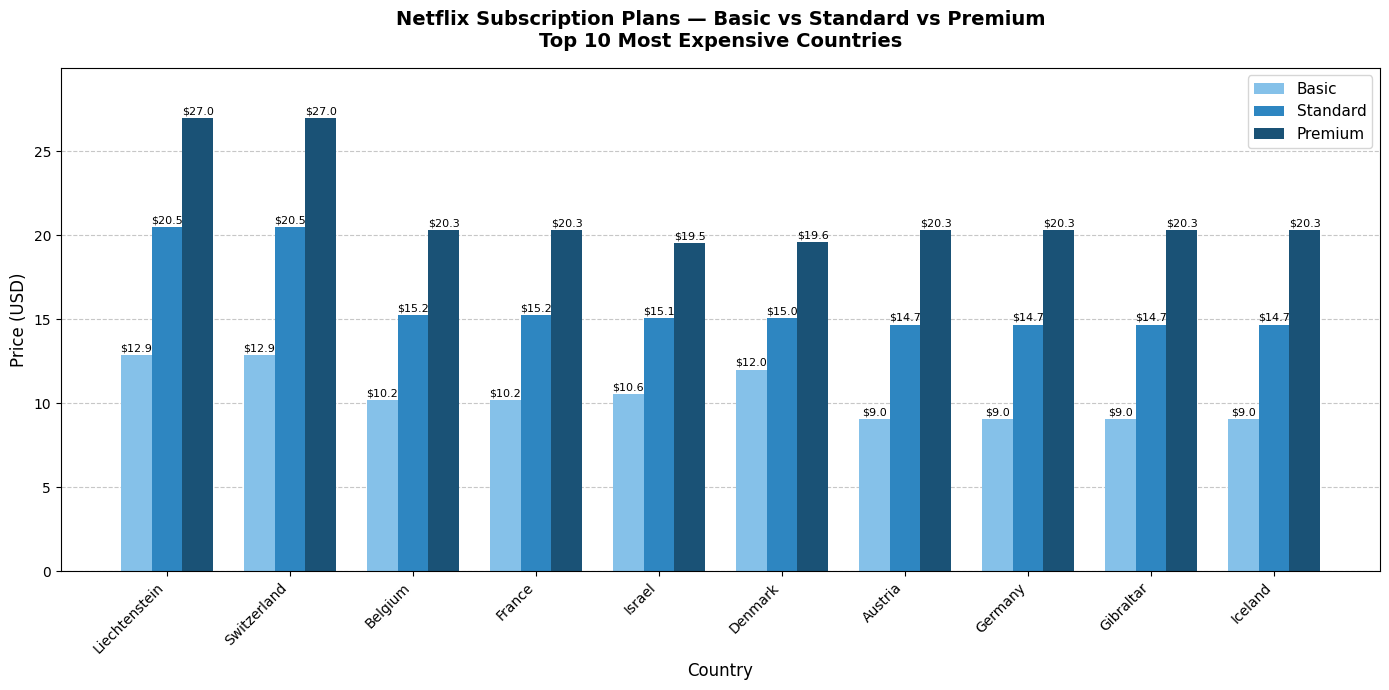

In [ ]:

# Data Visualisation
# TOP 10 MOST EXPENSIVE COUNTRIES

import numpy as np
import matplotlib.pyplot as plt


# Get top 10 most expensive by Standard plan
top10 = df_netflix_fee.nlargest(10, 'Cost Per Month - Standard ($)')

# Bar positions
x = np.arange(len(top10))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))

# 3 bars per country
bars1 = ax.bar(x - width, top10['Cost Per Month - Basic ($)'],
               width, label='Basic', color='#85C1E9')
bars2 = ax.bar(x, top10['Cost Per Month - Standard ($)'],
               width, label='Standard', color='#2E86C1')
bars3 = ax.bar(x + width, top10['Cost Per Month - Premium ($)'],
               width, label='Premium', color='#1A5276')

# Labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'${bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'${bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)
for bar in bars3:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'${bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

# Styling
ax.set_title('Netflix Subscription Plans — Basic vs Standard vs Premium\nTop 10 Most Expensive Countries',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Price (USD)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(top10['country'], rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=11)
ax.set_ylim(0, top10['Cost Per Month - Premium ($)'].max() + 3)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('RQ1_extra_plans_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


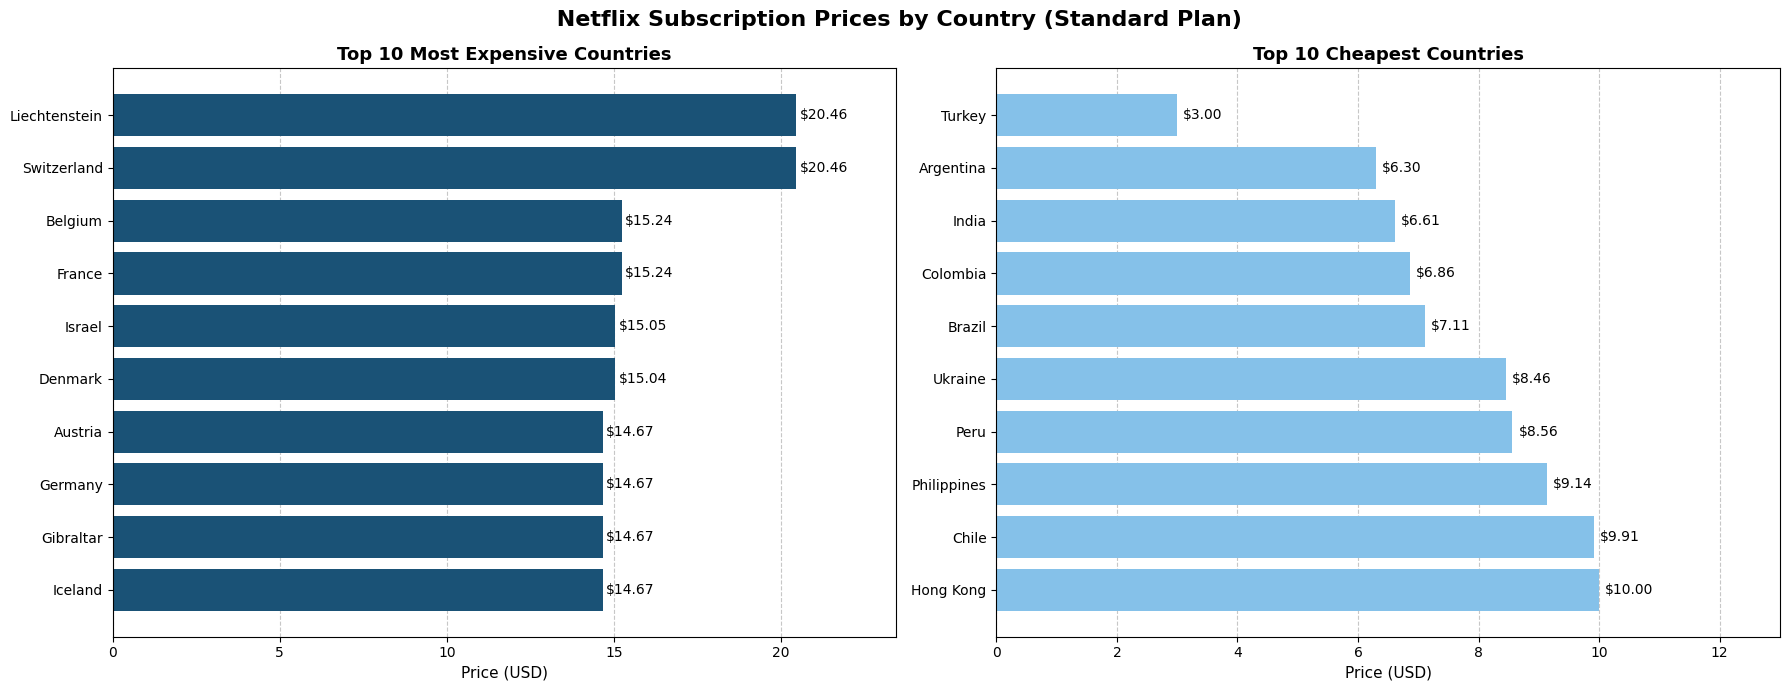

In [ ]:

# MOST & LEAST EXPENSIVE


fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(' Netflix Subscription Prices by Country (Standard Plan)',
             fontsize=16, fontweight='bold')

# --- Left chart: Top 10 most expensive ---
top10_expensive = df_netflix_fee.nlargest(10, 'Cost Per Month - Standard ($)')

axes[0].barh(top10_expensive['country'],
             top10_expensive['Cost Per Month - Standard ($)'],
             color='#1A5276')
axes[0].set_title('Top 10 Most Expensive Countries', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price (USD)', fontsize=11)
axes[0].invert_yaxis()
for i, val in enumerate(top10_expensive['Cost Per Month - Standard ($)']):
    axes[0].text(val + 0.1, i, f'${val:.2f}', va='center', fontsize=10)
axes[0].set_xlim(0, top10_expensive['Cost Per Month - Standard ($)'].max() + 3)
axes[0].xaxis.grid(True, linestyle='--', alpha=0.7)
axes[0].set_axisbelow(True)

# --- Right chart: Top 10 cheapest ---
top10_cheap = df_netflix_fee.nsmallest(10, 'Cost Per Month - Standard ($)')

axes[1].barh(top10_cheap['country'],
             top10_cheap['Cost Per Month - Standard ($)'],
             color='#85C1E9')
axes[1].set_title('Top 10 Cheapest Countries', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Price (USD)', fontsize=11)
axes[1].invert_yaxis()
for i, val in enumerate(top10_cheap['Cost Per Month - Standard ($)']):
    axes[1].text(val + 0.1, i, f'${val:.2f}', va='center', fontsize=10)
axes[1].set_xlim(0, top10_cheap['Cost Per Month - Standard ($)'].max() + 3)
axes[1].xaxis.grid(True, linestyle='--', alpha=0.7)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig('RQ1_main_country_prices.png', dpi=150, bbox_inches='tight')
plt.show()


/tmp/ipykernel_474/848034515.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_users,
/tmp/ipykernel_474/848034515.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plan_revenue,


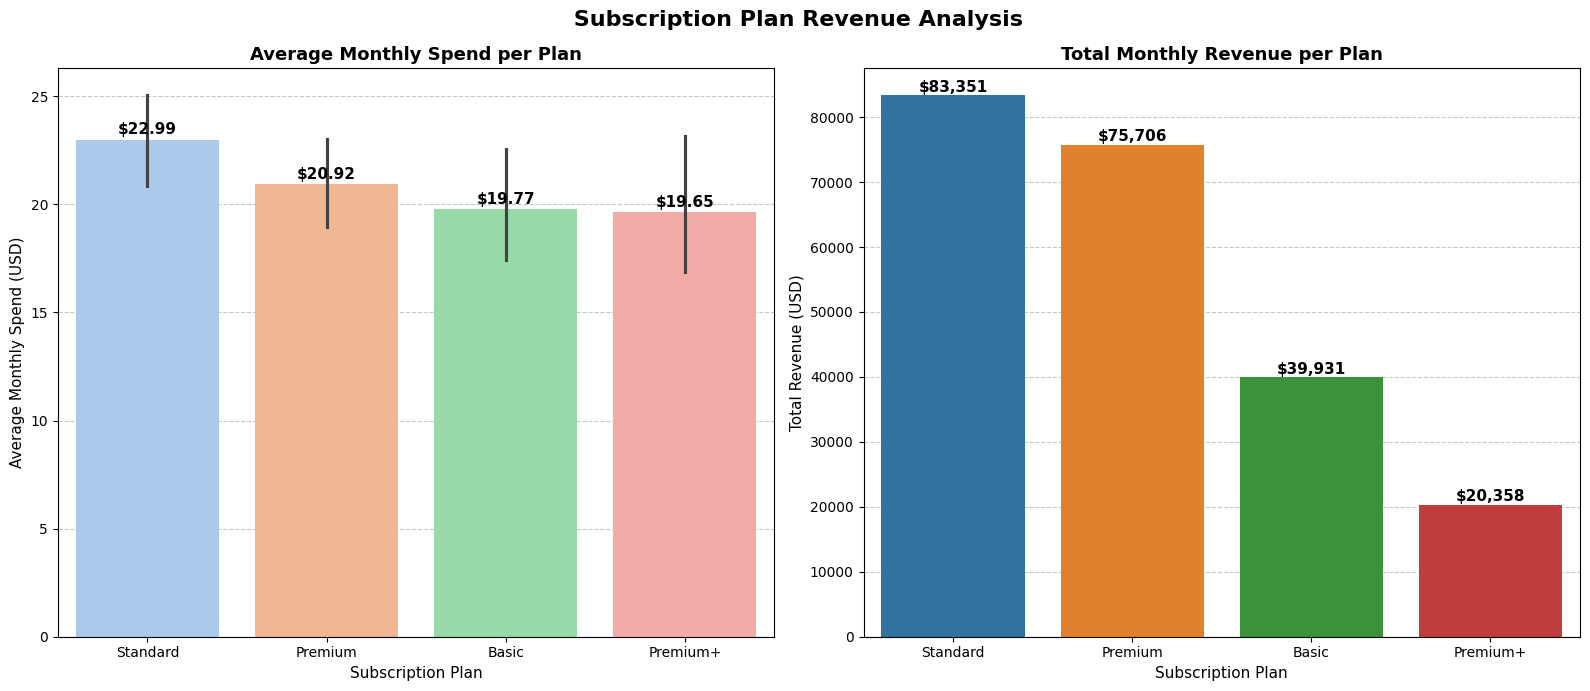

In [ ]:

# Q2 Which plan earns most revenue?
# SEABORN VERSION

import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(' Subscription Plan Revenue Analysis',
             fontsize=16, fontweight='bold')

# --- Left chart: Average monthly spend per plan ---
sns.barplot(data=df_users,
            x='subscription_plan',
            y='monthly_spend',
            estimator='mean',
            palette='pastel',
            order=df_users.groupby('subscription_plan')['monthly_spend'].mean()
                          .sort_values(ascending=False).index,
            ax=axes[0])

axes[0].set_title('Average Monthly Spend per Plan', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Subscription Plan', fontsize=11)
axes[0].set_ylabel('Average Monthly Spend (USD)', fontsize=11)

# Add value labels
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'${bar.get_height():.2f}',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[0].yaxis.grid(True, linestyle='--', alpha=0.7)
axes[0].set_axisbelow(True)

# --- Right chart: Total revenue per plan ---
plan_revenue = df_users.groupby('subscription_plan')['monthly_spend'].sum().reset_index()
plan_revenue.columns = ['subscription_plan', 'total_revenue']
plan_revenue = plan_revenue.sort_values('total_revenue', ascending=False)

sns.barplot(data=plan_revenue,
            x='subscription_plan',
            y='total_revenue',
            palette='tab10',
            order=plan_revenue['subscription_plan'],
            ax=axes[1])

axes[1].set_title('Total Monthly Revenue per Plan', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Subscription Plan', fontsize=11)
axes[1].set_ylabel('Total Revenue (USD)', fontsize=11)

# Add value labels
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 100,
                 f'${bar.get_height():,.0f}',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[1].yaxis.grid(True, linestyle='--', alpha=0.7)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig('RQ2_main_plan_revenue.png', dpi=150, bbox_inches='tight')
plt.show()


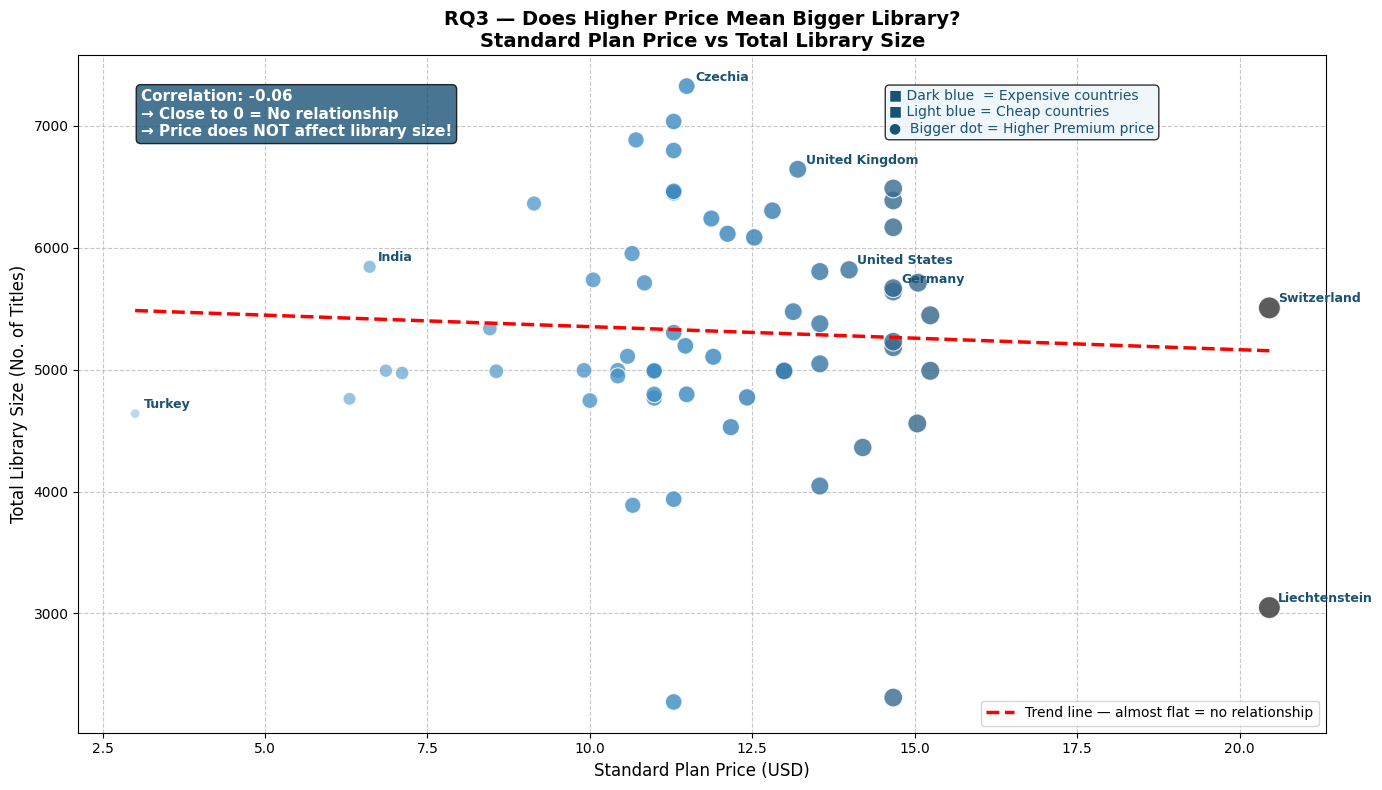

✅ RQ3 chart saved! Correlation = -0.06


In [ ]:
# ============================================
# RQ3 COMPLETE CODE — WITH TREND LINE
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(14, 8))

# Step 1 — Scatter plot
sns.scatterplot(data=df_netflix_fee,
                x='Cost Per Month - Standard ($)',
                y='Total Library Size',
                palette='Blues_d',
                hue='Cost Per Month - Standard ($)',
                size='Cost Per Month - Standard ($)',
                sizes=(50, 250),
                alpha=0.8,
                legend=False,
                ax=ax)

# Step 2 — Trend line
x_vals = df_netflix_fee['Cost Per Month - Standard ($)'].values
y_vals = df_netflix_fee['Total Library Size'].values

z = np.polyfit(x_vals, y_vals, 1)
p = np.poly1d(z)
x_line = np.linspace(x_vals.min(), x_vals.max(), 100)

ax.plot(x_line, p(x_line),
        color='red',
        linewidth=2.5,
        linestyle='--',
        zorder=10,
        label='Trend line — almost flat = no relationship')

# Step 3 — Country labels (key countries only)
highlight = ['Turkey', 'India', 'United States',
             'Liechtenstein', 'Switzerland',
             'Czechia', 'United Kingdom', 'Germany']

for _, row in df_netflix_fee.iterrows():
    if row['country'] in highlight:
        ax.annotate(row['country'],
                    xy=(row['Cost Per Month - Standard ($)'],
                        row['Total Library Size']),
                    xytext=(6, 4),
                    textcoords='offset points',
                    fontsize=9,
                    fontweight='bold',
                    color='#1A5276')

# Step 4 — Correlation value
corr = df_netflix_fee['Cost Per Month - Standard ($)'].corr(
       df_netflix_fee['Total Library Size'])

# Step 5 — Correlation box
ax.text(0.05, 0.95,
        f'Correlation: {corr:.2f}\n'
        '→ Close to 0 = No relationship\n'
        '→ Price does NOT affect library size!',
        transform=ax.transAxes,
        fontsize=11,
        fontweight='bold',
        verticalalignment='top',
        color='white',
        bbox=dict(boxstyle='round',
                  facecolor='#1A5276',
                  alpha=0.8))

# Step 6 — Color legend box
ax.text(0.65, 0.95,
        '■ Dark blue  = Expensive countries\n'
        '■ Light blue = Cheap countries\n'
        '●  Bigger dot = Higher Premium price',
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        color='#1A5276',
        bbox=dict(boxstyle='round',
                  facecolor='#EBF5FB',
                  alpha=0.8))

# Step 7 — Legend for trend line
ax.legend(loc='lower right', fontsize=10)

# Step 8 — Titles and labels
ax.set_title('RQ3 — Does Higher Price Mean Bigger Library?\n'
             'Standard Plan Price vs Total Library Size',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Standard Plan Price (USD)', fontsize=12)
ax.set_ylabel('Total Library Size (No. of Titles)', fontsize=12)

# Step 9 — Grid
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('RQ3_main_price_vs_library.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ RQ3 chart saved! Correlation = {corr:.2f}")

In [ ]:
# ============================================
# ADD REGION COLUMN TO df_netflix_fee
# ============================================

region_map = {
    # Europe
    'Germany': 'Europe', 'France': 'Europe', 'United Kingdom': 'Europe',
    'Spain': 'Europe', 'Italy': 'Europe', 'Netherlands': 'Europe',
    'Sweden': 'Europe', 'Norway': 'Europe', 'Denmark': 'Europe',
    'Finland': 'Europe', 'Belgium': 'Europe', 'Austria': 'Europe',
    'Switzerland': 'Europe', 'Portugal': 'Europe', 'Poland': 'Europe',
    'Czechia': 'Europe', 'Romania': 'Europe', 'Hungary': 'Europe',
    'Bulgaria': 'Europe', 'Slovakia': 'Europe', 'Croatia': 'Europe',
    'Estonia': 'Europe', 'Latvia': 'Europe', 'Lithuania': 'Europe',
    'Moldova': 'Europe', 'Ukraine': 'Europe', 'Greece': 'Europe',
    'Iceland': 'Europe', 'Ireland': 'Europe', 'Liechtenstein': 'Europe',
    'Monaco': 'Europe', 'Gibraltar': 'Europe', 'San Marino': 'Europe',
    'Russia': 'Europe',

    # Americas
    'United States': 'Americas', 'Canada': 'Americas',
    'Brazil': 'Americas', 'Mexico': 'Americas', 'Argentina': 'Americas',
    'Colombia': 'Americas', 'Chile': 'Americas', 'Peru': 'Americas',
    'Bolivia': 'Americas', 'Ecuador': 'Americas', 'Paraguay': 'Americas',
    'Uruguay': 'Americas', 'Venezuela': 'Americas',
    'Guatemala': 'Americas', 'Honduras': 'Americas', 'Costa Rica': 'Americas',

    # Asia Pacific
    'India': 'Asia Pacific', 'Japan': 'Asia Pacific',
    'South Korea': 'Asia Pacific', 'Australia': 'Asia Pacific',
    'New Zealand': 'Asia Pacific', 'Singapore': 'Asia Pacific',
    'Malaysia': 'Asia Pacific', 'Thailand': 'Asia Pacific',
    'Philippines': 'Asia Pacific', 'Indonesia': 'Asia Pacific',
    'Taiwan': 'Asia Pacific', 'Hong Kong': 'Asia Pacific',

    # Middle East & Africa
    'Israel': 'Middle East & Africa', 'South Africa': 'Middle East & Africa',
    'Turkey': 'Middle East & Africa',
}

df_netflix_fee['region'] = df_netflix_fee['country'].map(region_map)

print(df_netflix_fee['region'].value_counts())

region
Europe                  34
Americas                16
Asia Pacific            12
Middle East & Africa     3
Name: count, dtype: int64


/tmp/ipykernel_474/3317997507.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_price,
/tmp/ipykernel_474/3317997507.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')
/tmp/ipykernel_474/3317997507.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_library,
/tmp/ipykernel_474/3317997507.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')


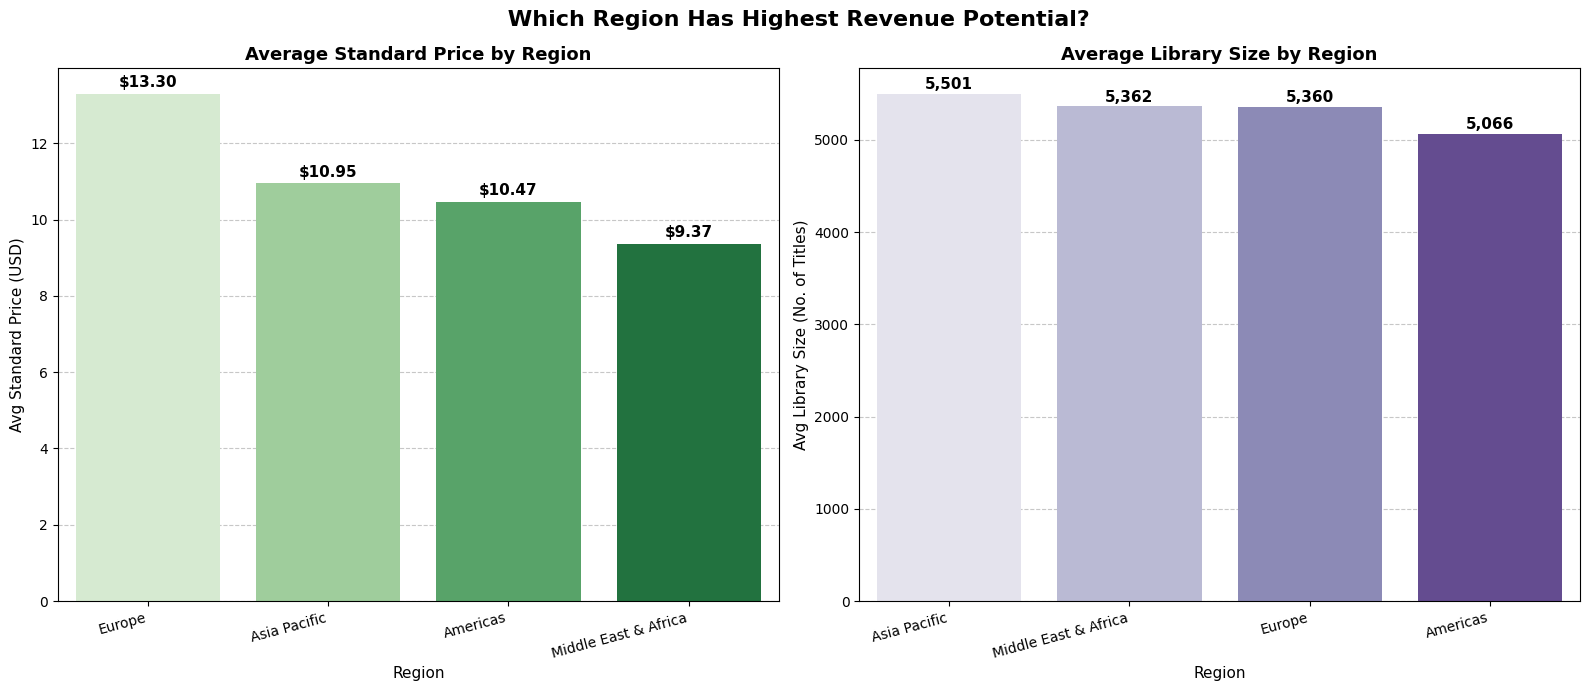

In [ ]:

# Q4 REVENUE POTENTIAL BY REGION


fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(' Which Region Has Highest Revenue Potential?',
             fontsize=16, fontweight='bold')

# --- Left chart: Average Standard price by region ---
region_price = df_netflix_fee.groupby('region')['Cost Per Month - Standard ($)'].mean().reset_index()
region_price = region_price.sort_values('Cost Per Month - Standard ($)', ascending=False)

sns.barplot(data=region_price,
            x='region',
            y='Cost Per Month - Standard ($)',
            palette='Greens',
            order=region_price['region'],
            ax=axes[0])

axes[0].set_title('Average Standard Price by Region', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Region', fontsize=11)
axes[0].set_ylabel('Avg Standard Price (USD)', fontsize=11)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')

for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'${bar.get_height():.2f}',
                 ha='center', va='bottom',
                 fontsize=11, fontweight='bold')

axes[0].yaxis.grid(True, linestyle='--', alpha=0.7)
axes[0].set_axisbelow(True)

# --- Right chart: Average library size by region ---
region_library = df_netflix_fee.groupby('region')['Total Library Size'].mean().reset_index()
region_library = region_library.sort_values('Total Library Size', ascending=False)

sns.barplot(data=region_library,
            x='region',
            y='Total Library Size',
            palette='Purples',
            order=region_library['region'],
            ax=axes[1])

axes[1].set_title('Average Library Size by Region', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Region', fontsize=11)
axes[1].set_ylabel('Avg Library Size (No. of Titles)', fontsize=11)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')

for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20,
                 f'{int(bar.get_height()):,}',
                 ha='center', va='bottom',
                 fontsize=11, fontweight='bold')

axes[1].yaxis.grid(True, linestyle='--', alpha=0.7)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig('main_region_revenue.png', dpi=150, bbox_inches='tight')
plt.show()


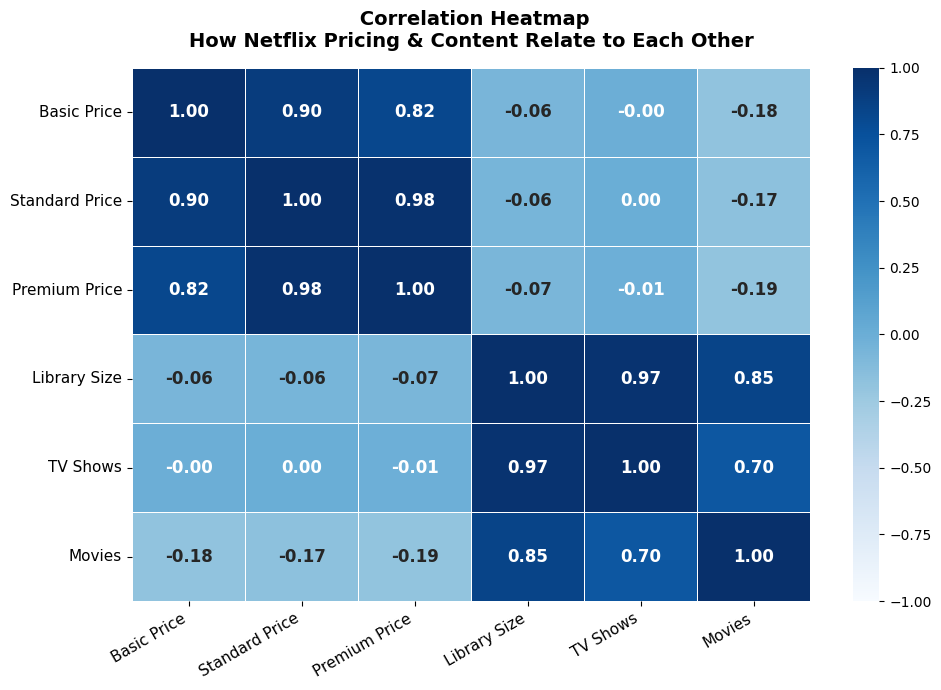

✅ Heatmap saved!


In [ ]:
# ============================================
# ADDITIONAL INSIGHT — CORRELATION HEATMAP
# ============================================

fig, ax = plt.subplots(figsize=(10, 7))

# Select relevant columns
heatmap_cols = df_netflix_fee[[
    'Cost Per Month - Basic ($)',
    'Cost Per Month - Standard ($)',
    'Cost Per Month - Premium ($)',
    'Total Library Size',
    'No. of TV Shows',
    'No. of Movies'
]]

# Rename columns for cleaner display
heatmap_cols.columns = [
    'Basic Price',
    'Standard Price',
    'Premium Price',
    'Library Size',
    'TV Shows',
    'Movies'
]

# Calculate correlation
corr_matrix = heatmap_cols.corr()

# Plot heatmap
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='Blues',
            linewidths=0.5,
            linecolor='white',
            vmin=-1, vmax=1,
            ax=ax,
            annot_kws={'size': 12, 'weight': 'bold'})

ax.set_title(' Correlation Heatmap\nHow Netflix Pricing & Content Relate to Each Other',
             fontsize=14, fontweight='bold', pad=15)

plt.xticks(fontsize=11, rotation=30, ha='right')
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()
plt.savefig('additional_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Heatmap saved!")

In [ ]:
# ============================================
# EXPORT CLEANED DATA FOR LOOKER STUDIO
# ============================================

# Export Dataset 1 — Netflix fee (main dataset for dashboard)
df_netflix_fee.to_csv('netflix_fee_clean.csv', index=False)
print(f" Netflix fee exported: {len(df_netflix_fee)} rows")

# Export users summary for plan analysis
df_users_summary = df_users.groupby(['country', 'subscription_plan']).agg(
    total_users=('user_id', 'count'),
    avg_monthly_spend=('monthly_spend', 'mean')
).reset_index()
df_users_summary.to_csv('netflix_users_summary.csv', index=False)
print(f"Users summary exported: {len(df_users_summary)} rows")

# Download both files
from google.colab import files
files.download('netflix_fee_clean.csv')
files.download('netflix_users_summary.csv')
print(" Both files downloaded!")

✅ Netflix fee exported: 65 rows
✅ Users summary exported: 8 rows


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Both files downloaded!


In [ ]:
# Check netflix_fee_clean.csv columns
import pandas as pd
df_check = pd.read_csv('netflix_fee_clean.csv')
print(df_check.columns.tolist())
print(df_check.shape)

['Country_code', 'Country', 'Total Library Size', 'No. of TV Shows', 'No. of Movies', 'Cost Per Month - Basic ($)', 'Cost Per Month - Standard ($)', 'Cost Per Month - Premium ($)']
(65, 8)
